<h2>Trader Performance vs Market Sentiment

<h3>Introduction</h3>

Market sentiment plays an important role in financial markets. Traders often make different decisions during periods of Fear and Greed, which can affect their overall performance. This project analyzes whether Bitcoin market sentiment has any relationship with the trading behavior and profitability of Hyperliquid traders.

<h3>Problem Statement</h3>

The objective is to understand whether traders perform differently during Fear and Greed market conditions and identify any trading patterns that can be used to improve decision-making.

<h3>Objectives</h3>
Clean and prepare both datasets.<br>
Merge trader data with the Fear & Greed Index using the date.<br>
Compare trader performance during Fear and Greed days.<br>
Analyze trading behavior such as trade frequency, position size, and leverage.<br>
Identify different trader segments.<br>
Provide practical trading recommendations based on the analysis.<br>

<h3>Steps:

step 1 : import libraries

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from IPython.display import display


step 2 : load data

In [129]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

step 3 : explore data

Historical data

In [130]:
trades.shape
trades.info()
trades.isnull().sum()
trades.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

np.int64(0)

Fear & Greed

In [131]:
sentiment.shape
sentiment.info()
sentiment.isnull().sum()
sentiment.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


np.int64(0)

Step 4 : Convert Date

Historical data

In [132]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"],format="%d-%m-%Y %H:%M")

In [133]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])
trades["Date"] = trades["Timestamp IST"].dt.date

fear and greed

In [134]:
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Date"] = sentiment["date"].dt.date

Check Date Range of both dataset

In [135]:
print(trades["Date"].min(), trades["Date"].max())
print(sentiment["Date"].min(), sentiment["Date"].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


check the datatype of both dataset

In [136]:
print(trades["Date"].dtype)
print(sentiment["Date"].dtype)

object
object


Check whether the dates actually match

In [137]:
common_dates = set(trades["Date"]) & set(sentiment["Date"])

print("Matching dates:", len(common_dates))
print(list(common_dates)[:10])

Matching dates: 479
[datetime.date(2024, 2, 16), datetime.date(2024, 9, 18), datetime.date(2024, 12, 31), datetime.date(2024, 10, 20), datetime.date(2024, 5, 16), datetime.date(2024, 9, 6), datetime.date(2024, 5, 23), datetime.date(2024, 7, 15), datetime.date(2025, 1, 30), datetime.date(2024, 1, 9)]


step 5 : merge

In [138]:
df = pd.merge(trades,sentiment[["Date", "classification", "value"]],on="Date",how="left")

Verify Merged Dataset

After merging the datasets, verify that the sentiment information has been correctly added to the trading data.

In [139]:
print("Shape of Merged Dataset:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
display(df[["classification", "value"]].isnull().sum())

print("\nMarket Sentiment Distribution:")
display(df["classification"].value_counts())

Shape of Merged Dataset:
(211224, 19)

First 5 Rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0



Missing Values:


classification    6
value             6
dtype: int64


Market Sentiment Distribution:


classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [141]:
df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,21.012784


In [142]:
df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
classification      6
value               6
dtype: int64

In [143]:
df.duplicated().sum()

np.int64(0)

step 7

Daily PnL per Trader

In [144]:
daily_pnl = (df.groupby(["Date", "Account"])["Closed PnL"].sum().reset_index())

daily_pnl.head()

,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


Win/Loss Column

In [145]:
df["Win"] = df["Closed PnL"] > 0

df["Win"].value_counts()

Win
False    124355
True      86869
Name: count, dtype: int64

Win rate

In [146]:
win_rate = (df.groupby("Account")["Win"].mean().mul(100).reset_index(name="Win Rate (%)"))

win_rate.head()

,Account,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


Average Trade Size

In [147]:
avg_trade = (df.groupby("Account")["Size USD"].mean().reset_index(name="Average Trade Size"))

avg_trade.head()

,Account,Average Trade Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


Trades Per Day

In [148]:
trades_per_day = (df.groupby("Date").size().reset_index(name="Total Trades"))

trades_per_day.head()

,Date,Total Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


Long vs Short Ratio

In [149]:
long_short = (df.groupby(["Date", "Side"]).size().unstack(fill_value=0))

long_short.head()

Side,BUY,SELL
Date,,
2023-05-01,3,0
2023-12-05,7,2
2023-12-14,5,6
2023-12-15,2,0
2023-12-16,3,0


In [150]:
performance = (df.groupby("classification").agg(
    Average_PnL=("Closed PnL", "mean"),
    Median_PnL=("Closed PnL", "median"),
    Win_Rate=("Win", "mean"),
    Total_Trades=("Closed PnL", "count")
    )
)
performance["Win_Rate"] = performance["Win_Rate"] * 100

performance.round(2)

,Average_PnL,Median_PnL,Win_Rate,Total_Trades
classification,,,,
Extreme Fear,34.54,0.0,37.06,21400
Extreme Greed,67.89,0.0,46.49,39992
Fear,54.29,0.0,42.08,61837
Greed,42.74,0.0,38.48,50303
Neutral,34.31,0.0,39.70,37686


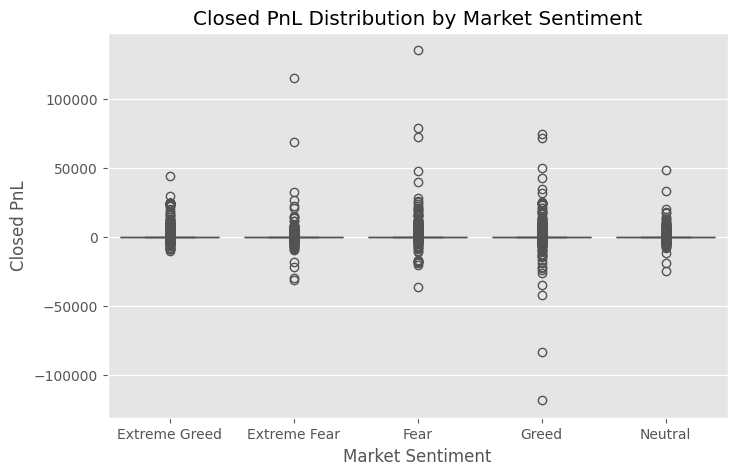

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

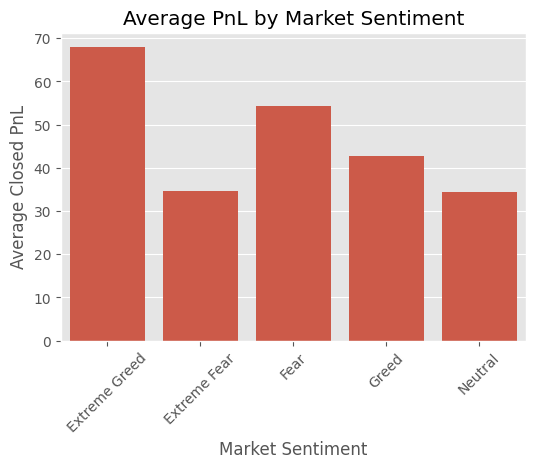

In [152]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="classification",
    y="Closed PnL",
    estimator="mean",
    errorbar=None
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.ylabel("Average Closed PnL")

plt.show()

Question 2: Do traders change behavior based on sentiment?

In [153]:
trade_frequency = (df.groupby("classification").size().reset_index(name="Number of Trades"))

trade_frequency

,classification,Number of Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


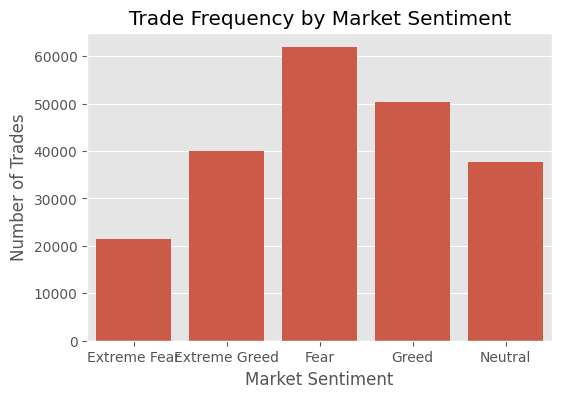

In [154]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=trade_frequency,
    x="classification",
    y="Number of Trades"
)

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Average Trade Size

In [155]:
trade_size = (
    df.groupby("classification")["Size USD"]
      .agg(["mean", "median"])
      .reset_index()
)

trade_size.columns = [
    "Classification",
    "Average Trade Size",
    "Median Trade Size"
]

trade_size.round(2)

,Classification,Average Trade Size,Median Trade Size
0,Extreme Fear,5349.73,766.15
1,Extreme Greed,3112.25,500.05
2,Fear,7816.11,735.96
3,Greed,5736.88,555.00
4,Neutral,4782.73,547.66


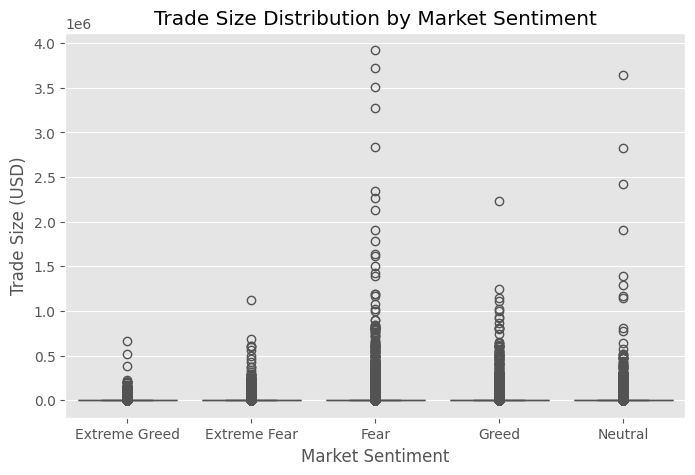

In [156]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="classification",
    y="Size USD"
)

plt.title("Trade Size Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (USD)")

plt.show()

Long vs Short Bias

In [157]:
long_short = (
    df.groupby(["classification", "Side"])
      .size()
      .unstack(fill_value=0)
)

long_short

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


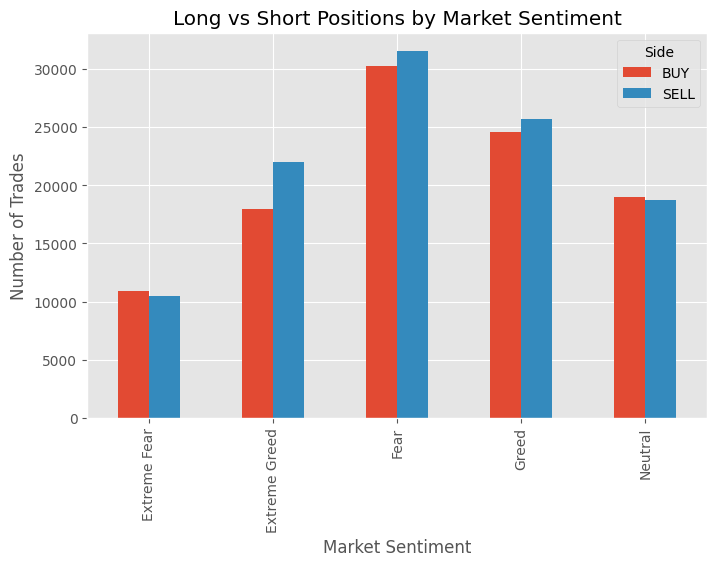

In [158]:
long_short.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Long vs Short Positions by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Average Trading Fee

In [159]:
fee_analysis = (
    df.groupby("classification")["Fee"]
      .agg(["mean", "median"])
      .reset_index()
)

fee_analysis.round(4)

,classification,mean,median
0,Extreme Fear,1.1163,0.1179
1,Extreme Greed,0.6759,0.0572
2,Fear,1.4952,0.1162
3,Greed,1.2544,0.0841
4,Neutral,1.0448,0.0899


summary table

In [160]:
behavior_summary = (
    df.groupby("classification")
      .agg(
          Total_Trades=("Account", "count"),
          Avg_Trade_Size=("Size USD", "mean"),
          Median_Trade_Size=("Size USD", "median"),
          Avg_Fee=("Fee", "mean")
      )
)

behavior_summary.round(2)

,Total_Trades,Avg_Trade_Size,Median_Trade_Size,Avg_Fee
classification,,,,
Extreme Fear,21400,5349.73,766.15,1.12
Extreme Greed,39992,3112.25,500.05,0.68
Fear,61837,7816.11,735.96,1.50
Greed,50303,5736.88,555.00,1.25
Neutral,37686,4782.73,547.66,1.04


Question 3: Identify 2–3 Trader Segments

In [161]:
trade_count = (
    df.groupby("Account")
      .size()
      .reset_index(name="Total_Trades")
)

trade_count.head()

,Account,Total_Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [162]:
median_trades = trade_count["Total_Trades"].median()

trade_count["Trader_Type"] = np.where(
    trade_count["Total_Trades"] >= median_trades,
    "Frequent Trader",
    "Infrequent Trader"
)

trade_count.head()

,Account,Total_Trades,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [163]:
trade_count["Trader_Type"].value_counts()

Trader_Type
Frequent Trader      16
Infrequent Trader    16
Name: count, dtype: int64

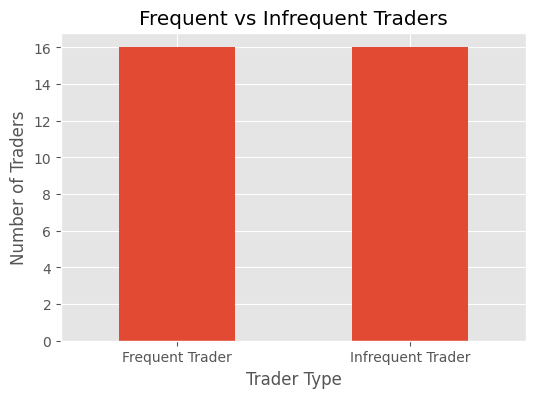

In [164]:
trade_count["Trader_Type"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Frequent vs Infrequent Traders")
plt.xlabel("Trader Type")
plt.ylabel("Number of Traders")
plt.xticks(rotation=0)
plt.show()

Segment 2: Consistent Winners vs Inconsistent Traders

In [165]:
df["Win"] = df["Closed PnL"] > 0

win_rate = (
    df.groupby("Account")["Win"]
      .mean()
      .reset_index()
)

win_rate["Win_Rate"] = win_rate["Win"] * 100
win_rate.drop("Win", axis=1, inplace=True)

win_rate.head()

,Account,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


In [166]:
win_rate["Trader_Type"] = np.where(
    win_rate["Win_Rate"] >= 50,
    "Consistent Winner",
    "Inconsistent Trader"
)

win_rate.head()

,Account,Win_Rate,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236,Inconsistent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978,Inconsistent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651,Inconsistent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463,Inconsistent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355,Consistent Winner


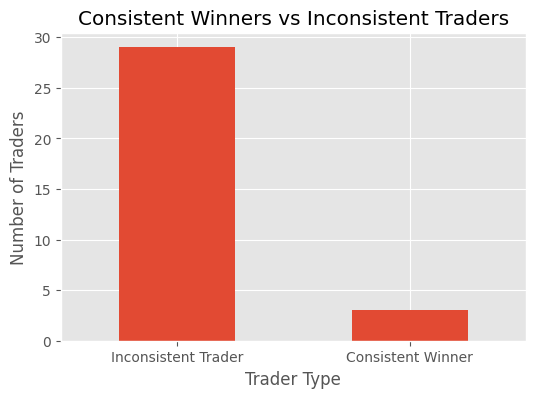

In [167]:
win_rate["Trader_Type"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Consistent Winners vs Inconsistent Traders")
plt.xlabel("Trader Type")
plt.ylabel("Number of Traders")
plt.xticks(rotation=0)
plt.show()

Segment 3: High Position Size vs Low Position Size Traders

In [168]:
position_size = (
    df.groupby("Account")["Size USD"]
      .mean()
      .reset_index(name="Avg_Position_Size")
)

position_size.head()

,Account,Avg_Position_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [169]:
median_size = position_size["Avg_Position_Size"].median()

position_size["Trader_Type"] = np.where(
    position_size["Avg_Position_Size"] >= median_size,
    "High Position Size",
    "Low Position Size"
)

position_size.head()

,Account,Avg_Position_Size,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734,High Position Size
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327,Low Position Size
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898,High Position Size
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933,Low Position Size
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782,Low Position Size


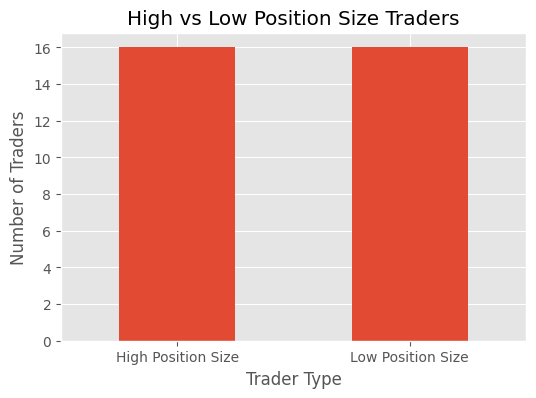

In [170]:
position_size["Trader_Type"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("High vs Low Position Size Traders")
plt.xlabel("Trader Type")
plt.ylabel("Number of Traders")
plt.xticks(rotation=0)
plt.show()

In [171]:
freq_perf = trade_count.merge(
    df.groupby("Account")["Closed PnL"].sum().reset_index(),
    on="Account"
)

freq_perf.groupby("Trader_Type")["Closed PnL"].mean()

Trader_Type
Frequent Trader      496527.661215
Infrequent Trader    147032.272750
Name: Closed PnL, dtype: float64

In [172]:
winner_perf = win_rate.merge(
    df.groupby("Account")["Closed PnL"].sum().reset_index(),
    on="Account"
)

winner_perf.groupby("Trader_Type")["Closed PnL"].mean()

Trader_Type
Consistent Winner      206866.631992
Inconsistent Trader    333667.553361
Name: Closed PnL, dtype: float64

In [173]:
size_perf = position_size.merge(
    df.groupby("Account")["Closed PnL"].sum().reset_index(),
    on="Account"
)

size_perf.groupby("Trader_Type")["Closed PnL"].mean()

Trader_Type
High Position Size    416805.966542
Low Position Size     226753.967423
Name: Closed PnL, dtype: float64

Question 4: Provide at least 3 insights backed by charts and tables

Insight 1: Trader Performance During Fear vs Greed

In [174]:
performance.round(2)

,Average_PnL,Median_PnL,Win_Rate,Total_Trades
classification,,,,
Extreme Fear,34.54,0.0,37.06,21400
Extreme Greed,67.89,0.0,46.49,39992
Fear,54.29,0.0,42.08,61837
Greed,42.74,0.0,38.48,50303
Neutral,34.31,0.0,39.70,37686


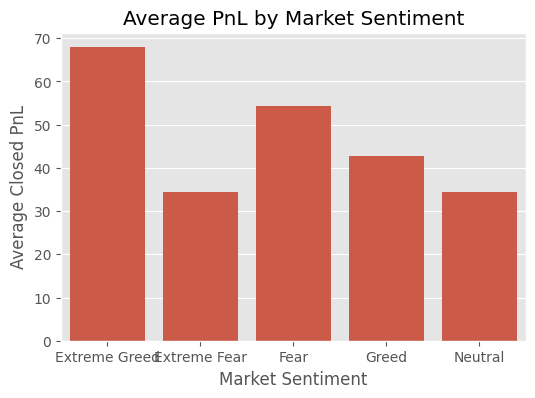

In [175]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="classification",
    y="Closed PnL",
    estimator="mean",
    errorbar=None
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

Insight 2: Trading Activity Changes with Market Sentiment

In [176]:
trade_frequency

,classification,Number of Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


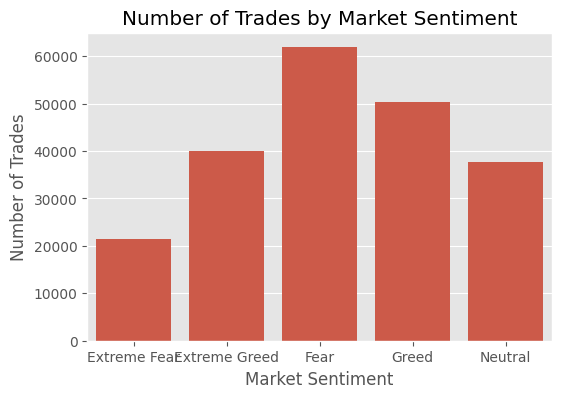

In [177]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=trade_frequency,
    x="classification",
    y="Number of Trades"
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Insight 3: Position Size and Risk-Taking Behavior

In [178]:
trade_size.round(2)

,Classification,Average Trade Size,Median Trade Size
0,Extreme Fear,5349.73,766.15
1,Extreme Greed,3112.25,500.05
2,Fear,7816.11,735.96
3,Greed,5736.88,555.00
4,Neutral,4782.73,547.66


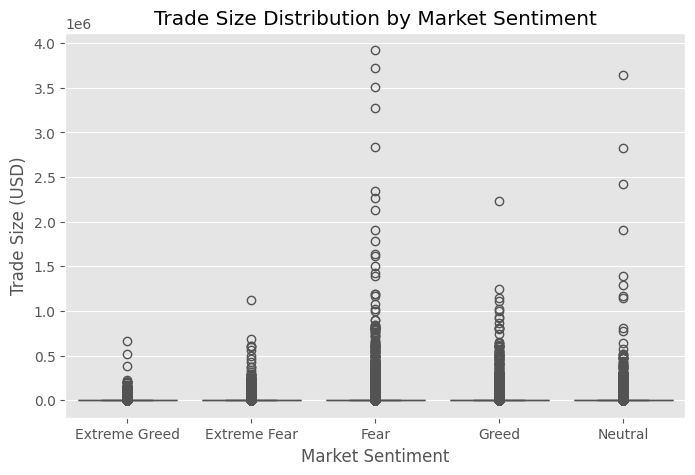

In [179]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="classification",
    y="Size USD"
)

plt.title("Trade Size Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (USD)")

plt.show()

Insight 4 (Optional): Long vs Short Preference

In [180]:
long_short

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


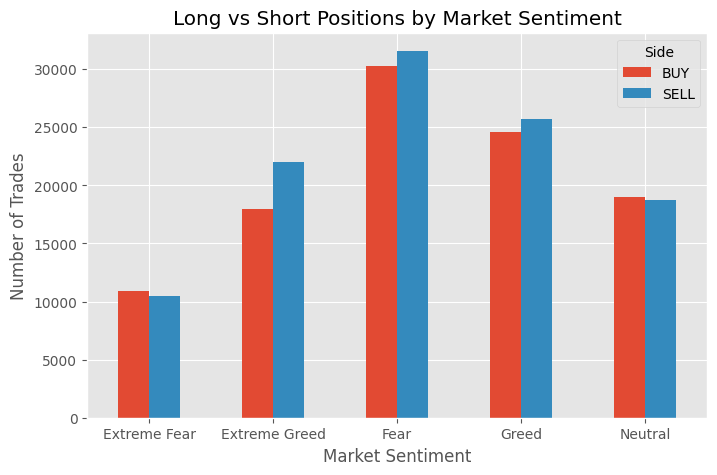

In [181]:
long_short.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Long vs Short Positions by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=0)

plt.show()

Predict

In [182]:
df["Profitable"] = np.where(df["Closed PnL"] > 0, 1, 0)

df["Profitable"].value_counts()

Profitable
0    124355
1     86869
Name: count, dtype: int64

In [183]:
features = [
    "value",        # Fear & Greed score
    "Size USD",
    "Execution Price",
    "Fee"
]

In [184]:
model_df = df[
    [
        "value",
        "classification",
        "Size USD",
        "Execution Price",
        "Side",
        "Direction",
        "Coin",
        "Fee",
        "Profitable"
    ]
].copy()

In [185]:
model_df.isnull().sum()

value              6
classification     6
Size USD           0
Execution Price    0
Side               0
Direction          0
Coin               0
Fee                0
Profitable         0
dtype: int64

In [186]:
model_df.dropna(inplace=True)

In [187]:
model_df = pd.get_dummies(
    model_df,
    columns=[
        "classification",
        "Side",
        "Direction",
        "Coin"
    ],
    drop_first=True
)

In [188]:
X = model_df.drop("Profitable", axis=1)
y = model_df["Profitable"]

In [189]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [190]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [191]:
y_pred = rf.predict(X_test)

In [192]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9830508474576272
Precision: 0.9705101406700186
Recall   : 0.9888332469924596
F1 Score : 0.97958601813309


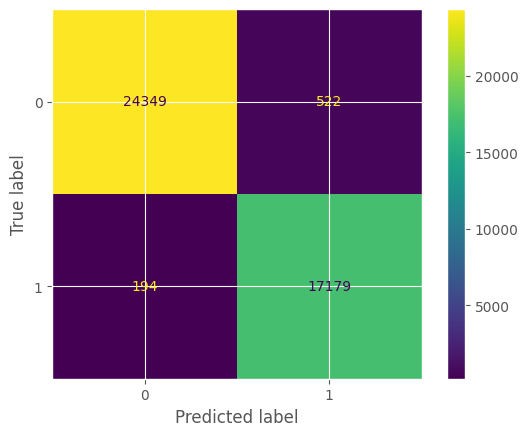

In [193]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [194]:
importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    }
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
10,Direction_Close Long,0.149592
14,Direction_Open Long,0.129395
15,Direction_Open Short,0.122913
2,Execution Price,0.115019
11,Direction_Close Short,0.100215
8,Side_SELL,0.060162
0,value,0.052998
3,Fee,0.049140
16,Direction_Sell,0.044662
1,Size USD,0.042689


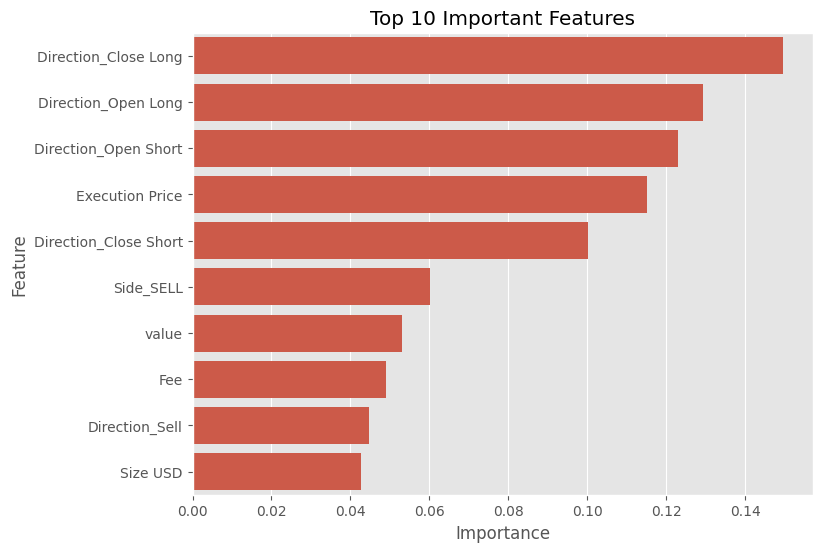

In [195]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [196]:
import pickle

In [197]:
import pickle
from sklearn.metrics import accuracy_score

# Predictions on test data
pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 98.31%


In [198]:
with open("profitability_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [199]:
with open("model_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [200]:
with open("model_accuracy.pkl", "wb") as f:
    pickle.dump(accuracy, f)